In [1]:
import numpy as np
import torch
print(np.__version__)    # should be 1.x.x
print(torch.__version__) # should be 2.2.0+cpu

1.26.4
2.2.0+cpu


### cell 1 — Load and inspect

In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df = pd.read_csv(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(df.head())
print(df.info())
print(df['Outcome'].value_counts())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null  

### Dataset is imbalanced: 65% non-diabetic, 35% diabetic. A model that predicts "no diabetes" every time would reach 65% accuracy — so accuracy alone is a misleading metric here.

### Cell 2

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome', axis=1).values # removes the Outcome column, leaving the 8 feature columns
y = df['Outcome'].values # converts the pandas DataFrame into a plain numpy array — scikit-learn and PyTorch both prefer numpy over pandas

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler() #  creates the scaler object — it doesn't do anything yet
X_train = scaler.fit_transform(X_train) #  looks at the training data, computes the mean and std of each feature, then rescales it
X_test  = scaler.transform(X_test)      # transform only — not fit_transform

# Quick check
print(X_train.shape)   # should be (614, 8)
print(X_test.shape)    # should be (154, 8)
print(X_train.mean().round(3))   # should be ~0.0 after scaling

(614, 8)
(154, 8)
0.0


* (614, 8) — 614 training samples, 8 features
* (154, 8) — 154 test samples, 8 features
* 0.0 — scaling worked, mean is centred at zero

 ### Cell 3 — DataLoader.

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t  = torch.tensor(y_train, dtype=torch.float32)
X_test_t   = torch.tensor(X_test,  dtype=torch.float32)
y_test_t   = torch.tensor(y_test,  dtype=torch.float32)

train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

print(f'Training batches: {len(train_loader)}')  
print(f'Tensor shape: {X_train_t.shape}')

Training batches: 20
Tensor shape: torch.Size([614, 8])


### cell 4 -  defining the model

In [7]:
import torch.nn as nn

class DiabetesNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 16)
        self.fc2 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = DiabetesNet()
print(model)

DiabetesNet(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

model.train()

for epoch in range(50):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        predictions = model(X_batch).squeeze()
        loss = criterion(predictions, y_batch.float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/50  Loss: {avg_loss:.4f}")

Epoch 10/50  Loss: 0.4424
Epoch 20/50  Loss: 0.4185
Epoch 30/50  Loss: 0.3917
Epoch 40/50  Loss: 0.3857
Epoch 50/50  Loss: 0.3753


### cell 6 - Evaluation

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

model.eval()
with torch.no_grad():
    logits = model(X_test_t).squeeze()
    probs  = torch.sigmoid(logits).numpy()

preds = (probs >= 0.5).astype(int)

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))
print('AUC:', round(roc_auc_score(y_test, probs), 3))

[[79 20]
 [20 35]]
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        99
           1       0.64      0.64      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154

AUC: 0.788


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]
print('Logistic Regression AUC:', round(roc_auc_score(y_test, lr_probs), 3))

Logistic Regression AUC: 0.815


#### My PyTorch neural network scored AUC 0.788 vs logistic regression's 0.815 on the same data. Neural networks are not always better — on small tabular datasets, simpler models often win. Neural networks become the right tool when data is large, high-dimensional, or has complex structure (images, signals, text).

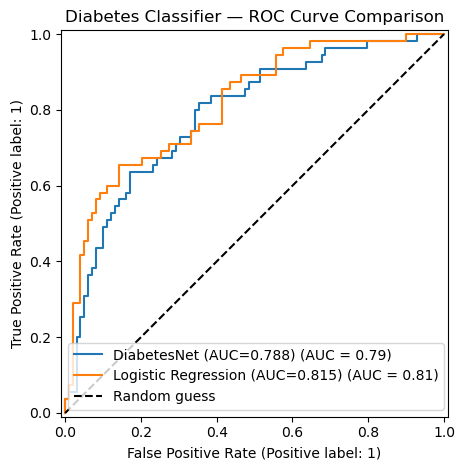

In [13]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, probs, name='DiabetesNet (AUC=0.788)')
RocCurveDisplay.from_predictions(y_test, lr_probs, name='Logistic Regression (AUC=0.815)', ax=plt.gca())

plt.title('Diabetes Classifier — ROC Curve Comparison')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()